In [7]:
import os
print(os.getcwd())
print(os.listdir())

C:\Users\HP
['.cache', '.idlerc', '.ipynb_checkpoints', '.ipython', '.jupyter', '.matplotlib', '.ms-ad', '.n8n', '.python_history', '.redhat', '.VirtualBox', '.vscode', '.vscode-shared', '01_Data_Analysis.ipynb', '02_Solar_Generation_Model.ipynb', '3D Objects', 'AppData', 'Application Data', 'book_project', 'Contacts', 'Cookies', 'Desktop', 'Documents', 'Downloads', 'exp4.ipynb', 'experiment4.ipynb', 'Favorites', 'Links', 'Local Settings', 'Music', 'My Documents', 'NetHood', 'notes_project', 'NTUSER.DAT', 'ntuser.dat.LOG1', 'ntuser.dat.LOG2', 'NTUSER.DAT{b0653486-f596-11ef-a2f3-935fe6b45291}.TM.blf', 'NTUSER.DAT{b0653486-f596-11ef-a2f3-935fe6b45291}.TMContainer00000000000000000001.regtrans-ms', 'NTUSER.DAT{b0653486-f596-11ef-a2f3-935fe6b45291}.TMContainer00000000000000000002.regtrans-ms', 'ntuser.ini', 'OneDrive', 'Pictures', 'PrintHood', 'Recent', 'Saved Games', 'Searches', 'SendTo', 'shreya', 'Start Menu', 'Templates', 'Untitled.ipynb', 'Videos', 'VirtualBox VMs']


In [8]:
import os

os.chdir(r"C:\Users\HP\Desktop\Solar_Project")

print(os.getcwd())

C:\Users\HP\Desktop\Solar_Project


In [10]:
import os

print("Current folder:")
print(os.getcwd())

print("\nFiles in folder:")
for file in os.listdir():
    print(file)

Current folder:
C:\Users\HP\Desktop\Solar_Project

Files in folder:
01_Data_Analysis.ipynb


In [11]:
import os

os.chdir(r"C:\Users\HP\Desktop\Solar_Project")

print(os.getcwd())

print(os.listdir())

C:\Users\HP\Desktop\Solar_Project
['01_Data_Analysis.ipynb']


In [13]:
import pandas as pd

df = pd.read_csv(r"C:\Users\HP\Desktop\Solar_Project\cleaned_solar_data.csv")

In [14]:
df.head()

,bat_current,bat_status,bat_volt,load_current,load_status,load_volt,pv_current,pv_volt,ft,hour,minute
0,5.70,1,26.3,4.28,1,32.7,0.0,0.0,0,0,2
1,5.59,1,26.8,4.19,1,33.4,0.0,0.0,0,0,2
2,5.59,1,26.8,4.19,1,33.4,0.0,0.0,0,0,2
3,5.59,1,26.8,4.19,1,33.4,0.0,0.0,0,0,2
4,5.59,1,26.8,4.19,1,33.4,0.0,0.0,0,0,2


In [15]:
df.columns

Index(['bat_current', 'bat_status', 'bat_volt', 'load_current', 'load_status',
       'load_volt', 'pv_current', 'pv_volt', 'ft', 'hour', 'minute'],
      dtype='object')

In [16]:
X = df[['bat_current',
        'bat_status',
        'bat_volt',
        'load_current',
        'load_status',
        'load_volt',
        'pv_volt',
        'ft',
        'hour',
        'minute']]

y = df['pv_current']

In [17]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training rows:", len(X_train))
print("Testing rows:", len(X_test))

Training rows: 128
Testing rows: 32


In [18]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor()

model.fit(X_train, y_train)

predictions = model.predict(X_test)

ValueError: could not convert string to float: 'LOAD ON AC'

In [19]:
df['load_status'].unique()

array(['1', 'LOAD ON AC', '0'], dtype=object)

In [20]:
df['load_status'] = df['load_status'].replace({
    'LOAD ON AC': 1,
    '1': 1,
    '0': 0
})

C:\Users\HP\AppData\Local\Temp\ipykernel_21612\450412862.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['load_status'] = df['load_status'].replace({


In [21]:
df['load_status'].unique()

array([1, 0])

In [24]:
df['load_status'].dtype

dtype('float64')

In [25]:
print(df.select_dtypes(include='object').columns)

Index([], dtype='object')


In [26]:
X = df[['bat_current',
        'bat_volt',
        'load_current',
        'load_volt',
        'pv_volt',
        'hour',
        'minute',
        'load_status']]

y = df['pv_current']

In [27]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2
)

In [28]:
#we use random forest algorithm to predict solar panel current . The dataset was divided into testing and training sets.
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor()

model.fit(X_train, y_train)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [29]:
predictions = model.predict(X_test)

In [30]:
from sklearn.metrics import mean_absolute_error

mae = mean_absolute_error(y_test, predictions)

print("MAE =", mae)

MAE = 0.03059374999999999


In [ ]:
#low error value indicates that the model was able to predict the current with good accuracy.

In [31]:
comparison = pd.DataFrame({
    'Actual': y_test,
    'Predicted': predictions
})

comparison.head(10)

,Actual,Predicted
114,0.0,0.000
57,0.0,0.000
130,0.0,0.000
61,0.0,0.415
129,0.0,0.000
24,0.0,0.000
110,0.0,0.000
7,0.0,0.000
109,0.0,0.000
131,0.0,0.000


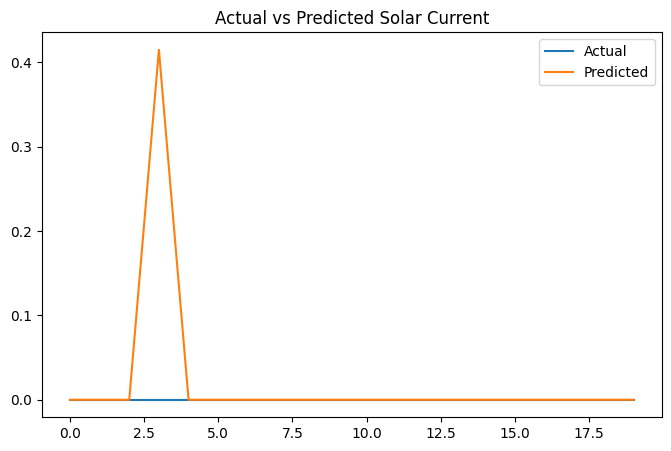

In [32]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(y_test.values[:20], label='Actual')
plt.plot(predictions[:20], label='Predicted')

plt.legend()
plt.title("Actual vs Predicted Solar Current")

plt.show()